In [59]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Lung X-Ray Image/Lung X-Ray Image/Normal/623.jpg
/kaggle/input/Lung X-Ray Image/Lung X-Ray Image/Normal/764.jpg
/kaggle/input/Lung X-Ray Image/Lung X-Ray Image/Normal/1075.jpg
/kaggle/input/Lung X-Ray Image/Lung X-Ray Image/Normal/771.jpg
/kaggle/input/Lung X-Ray Image/Lung X-Ray Image/Normal/208.jpg
/kaggle/input/Lung X-Ray Image/Lung X-Ray Image/Normal/820.jpg
/kaggle/input/Lung X-Ray Image/Lung X-Ray Image/Normal/473.jpg
/kaggle/input/Lung X-Ray Image/Lung X-Ray Image/Normal/1031.jpg
/kaggle/input/Lung X-Ray Image/Lung X-Ray Image/Normal/333.jpg
/kaggle/input/Lung X-Ray Image/Lung X-Ray Image/Normal/1024.jpg
/kaggle/input/Lung X-Ray Image/Lung X-Ray Image/Normal/537.jpg
/kaggle/input/Lung X-Ray Image/Lung X-Ray Image/Normal/45.jpg
/kaggle/input/Lung X-Ray Image/Lung X-Ray Image/Normal/369.jpg
/kaggle/input/Lung X-Ray Image/Lung X-Ray Image/Normal/56.jpg
/kaggle/input/Lung X-Ray Image/Lung X-Ray Image/Normal/654.jpg
/kaggle/input/Lung X-Ray Image/Lung X-Ray Image/Normal

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os 
import cv2
import tensorflow as tf
from tensorflow.keras import models,layers
from PIL import Image 
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization ,Input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tqdm import tqdm

In [60]:
datasets = ['/kaggle/input/Lung X-Ray Image/Lung X-Ray Image']

In [61]:
class_names_label={'Lung_Opacity': 0, 'Normal': 1, 'Viral Pneumonia': 2}

In [47]:
# "/"+os.listdir(datasets)[0]

In [48]:
# os.listdir(""+os.listdir(datasets)[0])

In [62]:
def load_data(datasets):
    images = []
    labels = []

    for dataset in datasets:
        print(f"Checking dataset path: {dataset}")
        if not os.path.exists(dataset):
            print(f"Dataset path does not exist: {dataset}")
            continue

        print(f"Loading {dataset}")
        for folder in os.listdir(dataset):
            label = class_names_label.get(folder)

            if label is not None:
                folder_path = os.path.join(dataset, folder)
                if not os.path.exists(folder_path):
                    print(f"Folder path does not exist: {folder_path}")
                    continue

                for file in tqdm(os.listdir(folder_path)):
                    img_path = os.path.join(folder_path, file)
                    image = cv2.imread(img_path)
                    if image is not None:
                        image = image / 255.0
                        image = cv2.resize(image, (260, 260))
                        images.append(image)
                        labels.append(label)

    images = np.array(images, dtype='float32')
    labels = np.array(labels, dtype='int32')

    return images, labels


In [63]:
image,labels=load_data(datasets)

Checking dataset path: /kaggle/input/Lung X-Ray Image/Lung X-Ray Image
Loading /kaggle/input/Lung X-Ray Image/Lung X-Ray Image


100%|██████████| 1100/1100 [00:09<00:00, 113.92it/s]


In [64]:
X_train, X_test, y_train, y_test = train_test_split(image, labels, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (2780, 260, 260, 3)
Testing data shape: (695, 260, 260, 3)


In [67]:
class_names = ['Lung_Opacity', 'Normal', 'Viral Pneumonia']


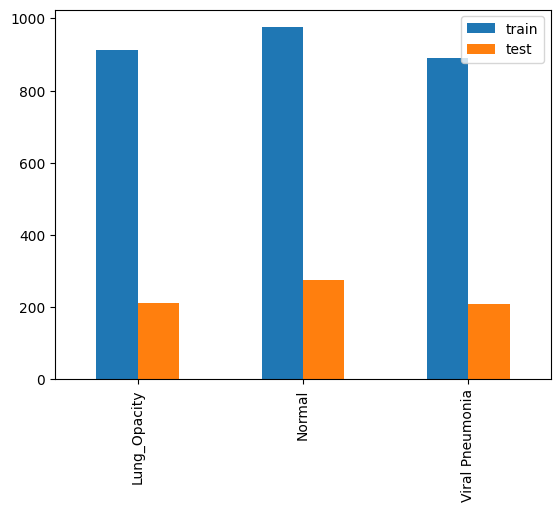

In [68]:
import pandas as pd

_, train_counts = np.unique(y_train, return_counts=True)
_, test_counts = np.unique(y_test, return_counts=True)
pd.DataFrame({'train': train_counts,
                    'test': test_counts}, 
             index=class_names
            ).plot.bar()
plt.show()

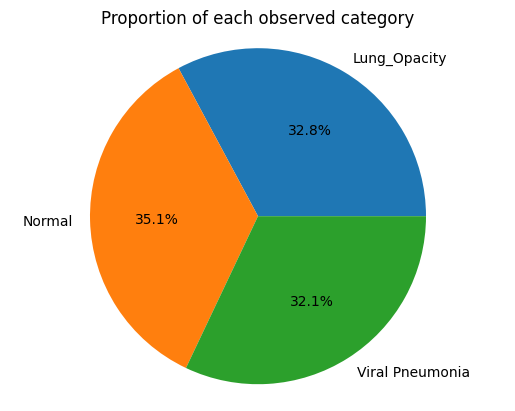

In [69]:
plt.pie(train_counts,
        explode=(0, 0, 0) , 
        labels=class_names,
        autopct='%1.1f%%')
plt.axis('equal')
plt.title('Proportion of each observed category')
plt.show()

In [70]:
def display_examples(class_names, images, labels):
    """
    Display 25 images from the images array with their corresponding labels.
    """
    class_names = ['Lung_Opacity', 'Normal', 'Viral Pneumonia']

    num_images = min(len(images), 25)  # Ensure there are at least 25 images
    fig = plt.figure(figsize=(10, 10))
    fig.suptitle("Some examples of images of the dataset", fontsize=16)
    
    for i in range(num_images):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        
        # Check if images are grayscale or color and display accordingly
        if images[i].shape[-1] == 1:  # Grayscale image
            plt.imshow(images[i].squeeze(), cmap=plt.cm.binary)
        else:  # Color image
            plt.imshow(images[i])
        
        plt.xlabel(class_names[labels[i]])
    
    plt.show()

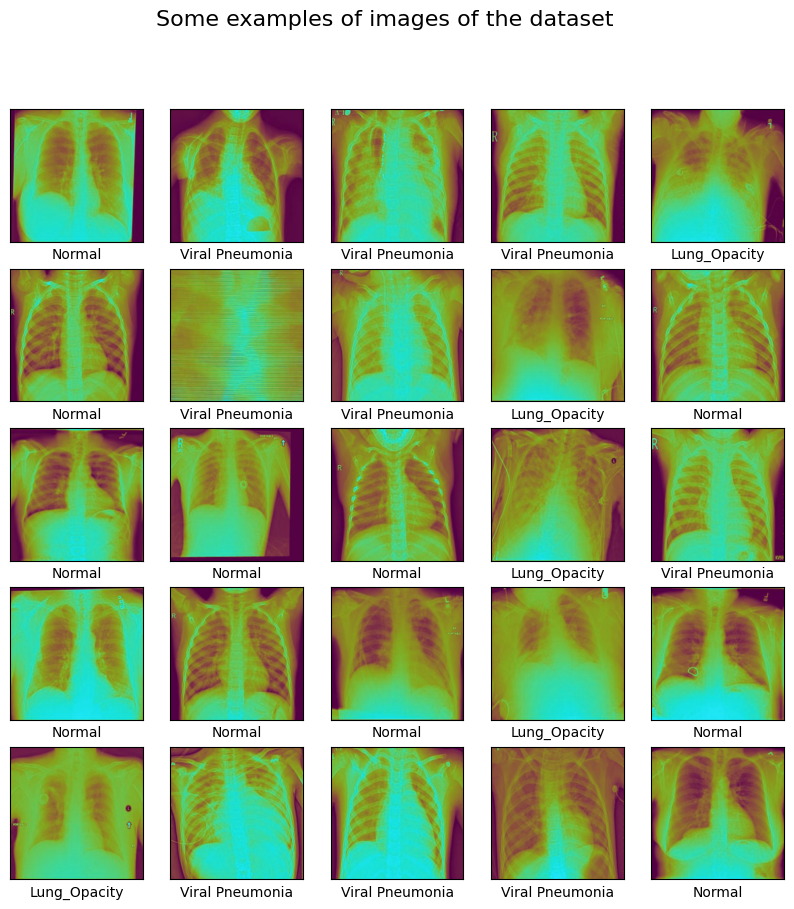

In [71]:
display_examples(class_names, X_train, y_train)

In [72]:
# Define the model
model = Sequential()

# Add Input layer
model.add(Input(shape=(260, 260, 3)))

# Add convolutional layers
model.add(Conv2D(128, kernel_size=5, activation='relu'))
model.add(MaxPool2D(2, 2))
model.add(Dropout(0.4))

model.add(Conv2D(64, kernel_size=3, activation='relu'))
model.add(MaxPool2D(2, 2))
model.add(Dropout(0.5))

model.add(Conv2D(32, kernel_size=3, activation='relu'))
model.add(MaxPool2D(2, 2))
model.add(Dropout(0.6))

# Flatten and Dense layers
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))

# Output layer
model.add(Dense(3, activation='softmax'))

In [73]:
model.compile(
    optimizer="adam",
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [74]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 128)  │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 61, 61, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     7,373,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,475,811 (28.52 MB)

 Trainable params: 7,475,811 (28.52 MB)

 Non-trainable params: 0 (0.00 B)

In [75]:
from keras.utils import to_categorical

y_train_one_hot = to_categorical(y_train, num_classes=3)


In [76]:
print("X_train shape:", X_train.shape)
print("y_train_one_hot shape:", y_train_one_hot.shape)


X_train shape: (2780, 260, 260, 3)
y_train_one_hot shape: (2780, 3)


In [77]:
history = model.fit(X_train, y_train_one_hot, batch_size=60,epochs=10, validation_split=0.2)

Epoch 1/10


I0000 00:00:1728073752.110580     205 service.cc:145] XLA service 0x7b1860218120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1728073752.110637     205 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1728073752.110641     205 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1728073773.354659     205 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.3447 - loss: 1.8962

I0000 00:00:1728073789.696527     204 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_1', 72 bytes spill stores, 72 bytes spill loads



38/38 ━━━━━━━━━━━━━━━━━━━━ 44s 559ms/step - accuracy: 0.3445 - loss: 1.8827 - val_accuracy: 0.3525 - val_loss: 1.0985
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 235ms/step - accuracy: 0.4065 - loss: 1.0265 - val_accuracy: 0.7194 - val_loss: 0.6916
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 236ms/step - accuracy: 0.7410 - loss: 0.6078 - val_accuracy: 0.7590 - val_loss: 0.6297
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 237ms/step - accuracy: 0.7700 - loss: 0.5581 - val_accuracy: 0.7896 - val_loss: 0.5327
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 239ms/step - accuracy: 0.7867 - loss: 0.5281 - val_accuracy: 0.8291 - val_loss: 0.5383
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 239ms/step - accuracy: 0.7993 - loss: 0.5094 - val_accuracy: 0.8022 - val_loss: 0.5022
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 240ms/step - accuracy: 0.8005 - loss: 0.4872 - val_accuracy: 0.8040 - val_loss: 0.4806
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 242ms/step - accuracy: 0.7911 - loss: 0.5172 - val_accuracy: 0.8219 - val

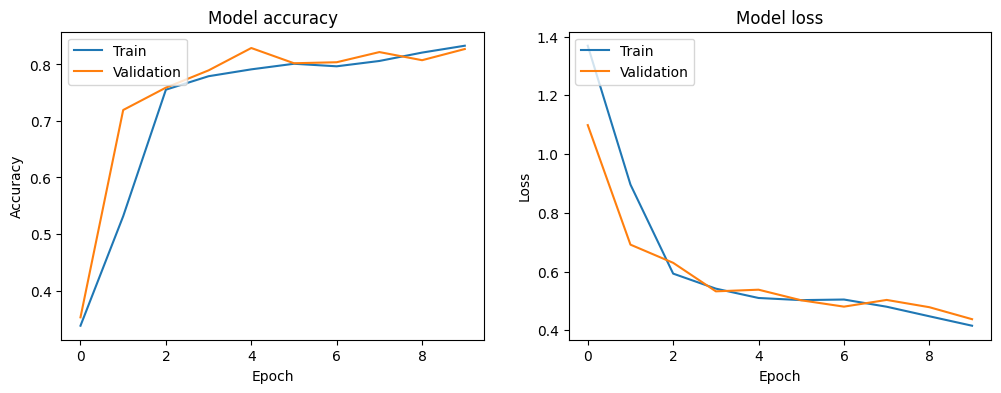

In [78]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()


In [79]:
from tensorflow.keras.utils import to_categorical

# One-hot encode test labels if necessary
y_test_one_hot = to_categorical(y_test, num_classes=3)


22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 179ms/step
Classification Report:
                 precision    recall  f1-score   support

   Lung_Opacity       0.84      0.70      0.76       212
         Normal       0.79      0.88      0.83       274
Viral Pneumonia       0.92      0.94      0.93       209

       accuracy                           0.84       695
      macro avg       0.85      0.84      0.84       695
   weighted avg       0.84      0.84      0.84       695



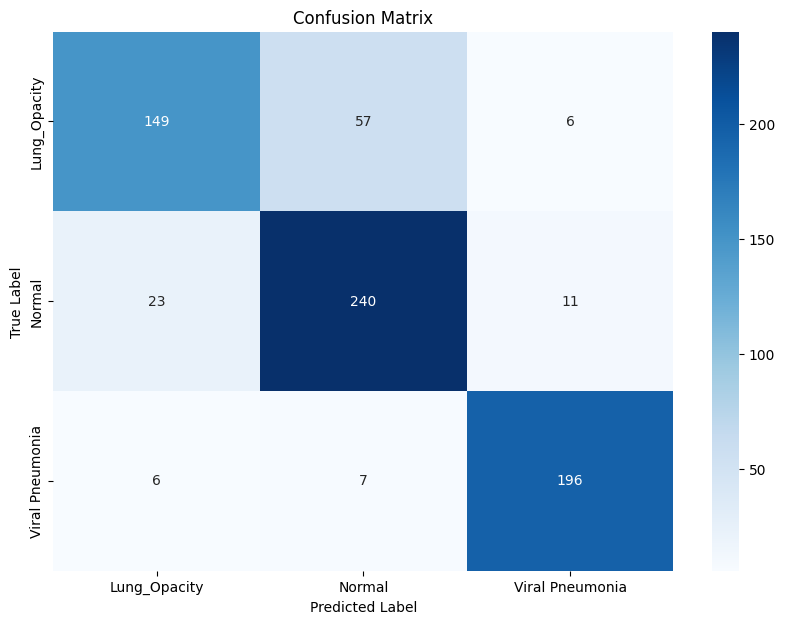

In [80]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)  # Get the class with highest probability

# Convert y_test_one_hot to class labels
y_test_labels = np.argmax(y_test_one_hot, axis=1)

# Generate a classification report
print("Classification Report:")
print(classification_report(y_test_labels, y_pred, target_names=class_names))

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test_labels, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


## 